## 1. Install and Import Libraries

Run the installation cell only if the packages are not already available in your environment.


In [1]:
# Install all external packages at the start of a fresh runtime.
# Use a T4 GPU runtime before running this notebook.
# The cu124 PyTorch wheel supports T4 (sm_75), but it is not safe for older P100-style GPUs.
# Do not reinstall torch after it has already been imported; restart the runtime first if needed.
%pip install -q ydata-profiling transformers accelerate safetensors packaging
%pip install -q torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import html
import warnings
from pathlib import Path

import glob
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from packaging.version import Version

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 200)
print('Libraries loaded.')


Libraries loaded.


## 2. Load Dataset

The helper function searches for CSV files across common locations (Kaggle, local, etc.) automatically.


In [3]:
def get_all_csv_files(base_dir='/kaggle/input'):
    """Return every CSV file inside Kaggle input folders."""
    return sorted(glob.glob(os.path.join(base_dir, '**', '*.csv'), recursive=True))


def choose_dataset_path(kind, csv_files):
    """
    Select the correct dataset path from available CSV files.

    kind:
    - 'train' for training dataset
    - 'test' for testing dataset
    """
    if kind == 'train':
        required_keywords = ['train', 'training']
        forbidden_keywords = ['test', 'testing']
    elif kind == 'test':
        required_keywords = ['test', 'testing']
        forbidden_keywords = ['train', 'training']
    else:
        raise ValueError("kind must be either 'train' or 'test'.")

    candidates = []

    for path in csv_files:
        filename = Path(path).name.lower()
        folder = str(Path(path).parent).lower()
        full_path = path.lower()

        has_required = any(keyword in filename or keyword in folder for keyword in required_keywords)
        has_forbidden = any(keyword in filename for keyword in forbidden_keywords)
        is_tiktok = 'tiktok' in full_path

        if is_tiktok and has_required and not has_forbidden:
            candidates.append(path)

    if not candidates:
        available = '\n'.join(csv_files)
        raise FileNotFoundError(
            f'Could not find the {kind} dataset automatically.\n\n'
            f'Available CSV files:\n{available}'
        )

    # Prefer real-world generated dataset if multiple files match.
    realworld_candidates = [
        path for path in candidates
        if 'realworld' in Path(path).name.lower()
    ]

    if realworld_candidates:
        return sorted(realworld_candidates)[0]

    return sorted(candidates)[0]


csv_files = get_all_csv_files('/kaggle/input')

print('Available CSV files under /kaggle/input:')
for path in csv_files:
    print('-', path)

if not csv_files:
    raise FileNotFoundError(
        'No CSV files were found under /kaggle/input. '
        'Please add your datasets using Add Input.'
    )

TRAIN_PATH = choose_dataset_path('train', csv_files)
TEST_PATH = choose_dataset_path('test', csv_files)

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Keep only the final recommended schema.
# IMPORTANT: score is loaded only for EDA/leakage checking, never as model input.
expected_columns = ['content', 'score', 'sentiment']

missing_train_cols = [col for col in expected_columns if col not in train_df.columns]
missing_test_cols = [col for col in expected_columns if col not in test_df.columns]

if missing_train_cols:
    raise ValueError(f'Training dataset is missing columns: {missing_train_cols}')

if missing_test_cols:
    raise ValueError(f'Testing dataset is missing columns: {missing_test_cols}')

train_df = train_df[expected_columns].copy()
test_df = test_df[expected_columns].copy()

print(f'Train : {train_df.shape[0]:,} rows x {train_df.shape[1]} columns  ->  {TRAIN_PATH}')
print(f'Test  : {test_df.shape[0]:,} rows x {test_df.shape[1]} columns   ->  {TEST_PATH}')

display(train_df.head(3))
display(test_df.head(3))

Available CSV files under /kaggle/input:
- /kaggle/input/datasets/jasonloiii/testing-dataset/tiktok_testing_realworld_4_5k.csv
- /kaggle/input/datasets/jasonloiii/training-dataset/tiktok_training_realworld_10k.csv
Train : 10,000 rows x 3 columns  ->  /kaggle/input/datasets/jasonloiii/training-dataset/tiktok_training_realworld_10k.csv
Test  : 4,500 rows x 3 columns   ->  /kaggle/input/datasets/jasonloiii/testing-dataset/tiktok_testing_realworld_4_5k.csv


,content,score,sentiment
0,"feedback kecil: pas mobile data dipakai. Aku cuma mau cek harga barang, tapi aplikasi sering force close. lama-lama bikin malas buka aplikasinya. versi v30.4.2 Masalahnya kerasa pas handle ukuran ...",1,negative
1,"catatan kecil: aku bandingin sama minggu lalu. Aku cuma mau lihat live diskon, tapi tab inbox lama kebuka. buat jualan malah bikin panik. (vivo Y21, Android 12) Di fitur search, link produk lepas ...",2,negative
2,"sebagai pengguna yang jarang komplain, laporan user: pas lagi nunggu bus aku buka. Awalnya aku ragu buat cari review gadget, tapi export video nggak pecah. rasanya lebih matang dari versi sebelumn...",3,positive


,content,score,sentiment
0,"sebagai orang yang cuma scroll malam, pas balas komentar customer, tombol beli langsung responsif, review barang jadi lebih mudah dicari buat kasusku hasilnya positif!!Di filter spam, kode promo t...",5,positive
1,"buat cari barang diskon, caption auto perlu edit ulang, tapi menghemat waktu, performa scroll lebih halus. jualan kecil jadi sedikit lebih gampang! #tiktokshop Cocok juga buat handle handmade saru...",4,positive
2,"waktu bikin draft review barang, filter spam komentar cukup efektif, buat aktivitas ringan ini menyenangkan sementara ini aman. #fyp Cocok juga buat handle rumahan kaos polos. Di pusat bantuan, la...",5,positive


In [4]:
# DEBUG: print all files under /kaggle/input/ to find the correct path
for root, dirs, files in os.walk('/kaggle/input/'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/jasonloiii/testing-dataset/tiktok_testing_realworld_4_5k.csv
/kaggle/input/datasets/jasonloiii/training-dataset/tiktok_training_realworld_10k.csv


## 3. Schema Validation and Data Quality

The `score` column is excluded from training because it correlates perfectly with `sentiment`, which would constitute data leakage.


In [5]:
REQUIRED = {'content', 'sentiment'}
for name, df in [('Train', train_df), ('Test', test_df)]:
    missing = REQUIRED - set(df.columns)
    if missing:
        raise ValueError(f'{name} set is missing required columns: {missing}')

# Drop rows with missing values in key columns
train_df = train_df.dropna(subset=list(REQUIRED)).copy()
test_df  = test_df.dropna(subset=list(REQUIRED)).copy()

# Normalize labels
for df in [train_df, test_df]:
    df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

print('=== Label Distribution ===')
dist = pd.DataFrame({
    'Train': train_df['sentiment'].value_counts(),
    'Test' : test_df['sentiment'].value_counts(),
})
display(dist)

print('\n=== Missing Values ===')
display(pd.DataFrame({
    'Train': train_df.isnull().sum(),
    'Test' : test_df.isnull().sum(),
}))

print('\n=== Duplicates ===')
print(f'Train : {train_df.duplicated(subset="content").sum()} duplicate rows')
print(f'Test  : {test_df.duplicated(subset="content").sum()} duplicate rows')
overlap = len(set(train_df['content']) & set(test_df['content']))
print(f'Train-test exact content overlap: {overlap} rows')


=== Label Distribution ===


,Train,Test
sentiment,,
positive,5500,2385
negative,4500,2115



=== Missing Values ===


,Train,Test
content,0,0
score,0,0
sentiment,0,0



=== Duplicates ===
Train : 0 duplicate rows
Test  : 0 duplicate rows
Train-test exact content overlap: 0 rows


## 4. Exploratory Data Analysis

Visualize label distributions and text length across train and test sets.


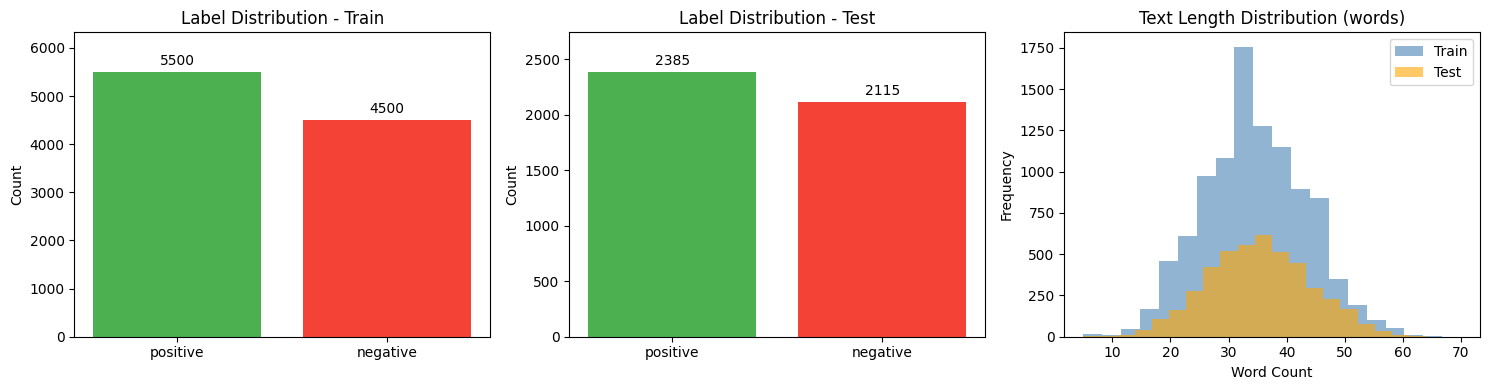

Text length statistics (words):


,Train,Test
count,10000.0,4500.0
mean,34.4,35.3
std,8.8,8.9
min,5.0,5.0
25%,28.0,29.0
50%,34.0,35.0
75%,40.0,41.0
max,70.0,64.0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label distribution
for ax, (name, df) in zip(axes[:2], [('Train', train_df), ('Test', test_df)]):
    counts = df['sentiment'].value_counts()
    colors = ['#4CAF50' if l == 'positive' else '#F44336' for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors)
    ax.bar_label(bars, fmt='%d', padding=3)
    ax.set_title(f'Label Distribution - {name}')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.15)

# Word count distribution
train_df['word_count'] = train_df['content'].str.split().str.len()
test_df['word_count']  = test_df['content'].str.split().str.len()
axes[2].hist(train_df['word_count'], bins=20, alpha=0.6, label='Train', color='steelblue')
axes[2].hist(test_df['word_count'],  bins=20, alpha=0.6, label='Test',  color='orange')
axes[2].set_title('Text Length Distribution (words)')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()

print('Text length statistics (words):')
display(pd.DataFrame({
    'Train': train_df['word_count'].describe(),
    'Test' : test_df['word_count'].describe(),
}).round(1))


## 5. Profiling Report

Generate an automated EDA report using ydata-profiling and save it as an HTML file.


In [7]:
try:
    from ydata_profiling import ProfileReport
    profile_train = ProfileReport(train_df, title='TikTok Training Report', minimal=True)
    profile_test  = ProfileReport(test_df,  title='TikTok Testing Report',  minimal=True)
    profile_train.to_file('tiktok_training_profile.html')
    profile_test.to_file('tiktok_testing_profile.html')
    print('Profiling reports saved.')
    profile_train.to_notebook_iframe()
except ImportError:
    print('ydata-profiling not available. Run: %pip install -q ydata-profiling')


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 10.09it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

...


100%|██████████| 4/4 [00:00<00:00, 24.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling reports saved.


## 6. Train-Test Phrase Overlap Check

Measures how many phrases are shared between train and test. A high overlap rate may indicate data contamination. Note: this dataset is fully synthetic, so some overlap from shared generation templates is expected.


In [8]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def build_ngrams(series, n):
    grams = set()
    for text in series.astype(str):
        tokens = normalize_text(text).split()
        grams.update(tuple(tokens[i:i+n]) for i in range(max(0, len(tokens) - n + 1)))
    return grams

print(f"{'N':>4} | {'Shared':>8} | {'Test Total':>10} | {'Overlap Rate':>12}")
print('-' * 42)
for n in [3, 4, 5]:
    tg = build_ngrams(train_df['content'], n)
    eg = build_ngrams(test_df['content'],  n)
    shared = len(tg & eg)
    rate   = shared / max(1, len(eg))
    print(f'{n:>4} | {shared:>8,} | {len(eg):>10,} | {rate:>11.2%}')


   N |   Shared | Test Total | Overlap Rate
------------------------------------------
   3 |   11,137 |     34,537 |      32.25%
   4 |   12,587 |     53,288 |      23.62%
   5 |   11,862 |     70,454 |      16.84%


## 7. Text Cleaning

A custom transformer compatible with the sklearn Pipeline. Cleans Indonesian TikTok review text while preserving sentiment signals.

**Cleaning steps:**

1. HTML unescape - decode HTML entities (e.g., `&amp;`)
2. Lowercase - normalize letter casing
3. Remove URLs, mentions, and hashtags
4. Emoji to sentiment token - converts emojis to meaningful text tokens rather than discarding them, since emojis carry strong sentiment signals (e.g., sad face -> `EMOJI_SAD`)
5. Repeated punctuation to token - `!!` or `?!` becomes `EXCL`, signaling strong emotion
6. Repeated characters - normalize typos (e.g., `bangeet` -> `bangeet` -> normalized)
7. Remove remaining non-alphanumeric characters and normalize whitespace


In [9]:
class TextCleaner(BaseEstimator, TransformerMixin):
    """
    Clean Indonesian TikTok review text for sentiment classification.

    Steps: HTML unescape, lowercase, remove URLs/mentions/hashtags,
    convert emojis to sentiment tokens, normalize repeated punctuation
    and characters, remove remaining noise.
    """

    EMOJI_MAP = [
        (r'[\U0001F620\U0001F621\U0001F92C\U0001F624]+',          'EMOJI_ANGRY'),
        (r'[\U0001F62D\U0001F622\U0001F614\U0001F97A\U0001F625]+', 'EMOJI_SAD'),
        (r'[\U0001F60A\U0001F970\U0001F604\U0001F60D\U00002764]+', 'EMOJI_HAPPY'),
        (r'[\U0001F923\U0001F602\U0001F606]+',                     'EMOJI_LAUGH'),
        (r'[\U0001F612\U0001F643\U0001F611\U0001F644]+',           'EMOJI_SARCASTIC'),
        (r'[\U0001F4AF\U0001F525\U0001F44D]+',                     'EMOJI_POSITIVE'),
    ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return pd.Series(X).astype(str).map(self._clean).values

    def _clean(self, text):
        # 1. HTML unescape
        text = html.unescape(str(text))
        # 2. Lowercase
        text = text.lower()
        # 3. Remove URLs, mentions, hashtags
        text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
        text = re.sub(r'@\w+', ' ', text)
        text = re.sub(r'#\w+', ' ', text)
        # 4. Convert emojis to sentiment tokens
        for pattern, token in self.EMOJI_MAP:
            text = re.sub(pattern, f' {token} ', text)
        text = text.encode('ascii', 'ignore').decode('ascii')
        # 5. Repeated punctuation -> token
        text = re.sub(r'[!?]{2,}', ' EXCL ', text)
        text = re.sub(r'\.{2,}',   ' ',      text)
        # 6. Normalize repeated characters (typos)
        text = re.sub(r'(\w)\1{2,}', r'\1\1', text)
        # 7. Remove non-alphanumeric characters and normalize whitespace
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
        return re.sub(r'\s+', ' ', text).strip()


# Preview cleaning results
cleaner = TextCleaner()
preview = pd.DataFrame({
    'original': train_df['content'].head(8).values,
    'cleaned' : cleaner.transform(train_df['content'].head(8)),
})
display(preview)


,original,cleaned
0,"feedback kecil: pas mobile data dipakai. Aku cuma mau cek harga barang, tapi aplikasi sering force close. lama-lama bikin malas buka aplikasinya. versi v30.4.2 Masalahnya kerasa pas handle ukuran ...",feedback kecil pas mobile data dipakai aku cuma mau cek harga barang tapi aplikasi sering force close lama lama bikin malas buka aplikasinya versi v30 4 2 masalahnya kerasa pas handle ukuran kecil...
1,"catatan kecil: aku bandingin sama minggu lalu. Aku cuma mau lihat live diskon, tapi tab inbox lama kebuka. buat jualan malah bikin panik. (vivo Y21, Android 12) Di fitur search, link produk lepas ...",catatan kecil aku bandingin sama minggu lalu aku cuma mau lihat live diskon tapi tab inbox lama kebuka buat jualan malah bikin panik vivo y21 android 12 di fitur search link produk lepas dari video
2,"sebagai pengguna yang jarang komplain, laporan user: pas lagi nunggu bus aku buka. Awalnya aku ragu buat cari review gadget, tapi export video nggak pecah. rasanya lebih matang dari versi sebelumn...",sebagai pengguna yang jarang komplain laporan user pas lagi nunggu bus aku buka awalnya aku ragu buat cari review gadget tapi export video nggak pecah rasanya lebih matang dari versi sebelumnya di...
3,"aku install lagi kemarin, saldo promosi nggak keupdate, rasanya seperti dipaksa jadi beta tester aku tunggu update perbaikan? #fyp Di keranjang, laporan retur gagal diunduh. Setelah dicoba 18 pers...",aku install lagi kemarin saldo promosi nggak keupdate rasanya seperti dipaksa jadi beta tester aku tunggu update perbaikan di keranjang laporan retur gagal diunduh setelah dicoba 18 persen baterai...
4,"hasilnya lebih rapi dibanding bulan lalu, mode dark-nya nyyaman, rasanya lebih matang dari versi sebelumnya!! #tiktokshop imo di Manado Cocok juga buat handle quick order sabun muka. Setelah dicob...",hasilnya lebih rapi dibanding bulan lalu mode dark nya nyyaman rasanya lebih matang dari versi sebelumnya imo di manado cocok juga buat handle quick order sabun muka setelah dicoba 28 order cukup ...
5,"sebagai seller pemula aku ngerasain, notifikasi order masuk cepat, feelnya smooth. aku bakal pantau update berikutnya... #reviewjujur deh Di live control room, insight penonton dibagi per jam.",sebagai seller pemula aku ngerasain notifikasi order masuk cepat feelnya smooth aku bakal pantau update berikutnya deh di live control room insight penonton dibagi per jam
6,"sebagai seller mainan anak, Buat cek harga barang, keranjang belanja seirng kosong sendiri. produk serum wajah jadi susah diproses, capek sendiri ngulang dari awal!! asli",sebagai seller mainan anak buat cek harga barang keranjang belanja seirng kosong sendiri produk serum wajah jadi susah diproses capek sendiri ngulang dari awal asli
7,"di Cikarang, pengalaman singkat: dari sisi penonton biasa. Awalnya aku ragu buat lihat live diskon, tapi caption otomatis lumayan rapi. ini update yang kerasa manfaatnya. #update lah",di cikarang pengalaman singkat dari sisi penonton biasa awalnya aku ragu buat lihat live diskon tapi caption otomatis lumayan rapi ini update yang kerasa manfaatnya lah


## 8. Train-Validation Split

The test set is kept untouched until final evaluation. A validation set is carved out from the training data for hyperparameter tuning.


In [10]:
X      = train_df['content'].astype(str)
y      = train_df['sentiment'].astype(str)
X_test = test_df['content'].astype(str)
y_test = test_df['sentiment'].astype(str)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train split      : {X_train.shape[0]:,} samples')
print(f'Validation split : {X_val.shape[0]:,} samples')
print(f'Test split       : {X_test.shape[0]:,} samples')
print()
print('Label proportions per split:')
display(pd.DataFrame({
    'Train': y_train.value_counts(normalize=True).round(3),
    'Val'  : y_val.value_counts(normalize=True).round(3),
    'Test' : y_test.value_counts(normalize=True).round(3),
}))


Train split      : 8,000 samples
Validation split : 2,000 samples
Test split       : 4,500 samples

Label proportions per split:


,Train,Val,Test
sentiment,,,
positive,0.55,0.55,0.53
negative,0.45,0.45,0.47


## 9. Baseline Model (TF-IDF + LinearSVC)

TF-IDF with LinearSVC is a strong baseline for short text classification. Results here serve as a reference point before hyperparameter tuning.


In [11]:
#  Shared TF-IDF settings 
TFIDF_PARAMS = dict(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    max_features=25000,
    sublinear_tf=True,
)

#  Define 4 pipelines 
pipelines = {
    'Logistic Regression': Pipeline([
        ('cleaner', TextCleaner()),
        ('tfidf',   TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',     LogisticRegression(C=0.5, class_weight='balanced',
                                       max_iter=2000, n_jobs=-1, random_state=42)),
    ]),
    'SVM (Linear Kernel)': Pipeline([
        ('cleaner', TextCleaner()),
        ('tfidf',   TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',     SVC(kernel='linear', C=0.5, class_weight='balanced',
                        probability=True, random_state=42)),
    ]),
    'Naive Bayes': Pipeline([
        ('cleaner', TextCleaner()),
        ('tfidf',   TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',     MultinomialNB(alpha=0.5)),
    ]),
    'Random Forest': Pipeline([
        ('cleaner', TextCleaner()),
        ('tfidf',   TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',     RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                           n_jobs=-1, random_state=42)),
    ]),
}

#  Train & evaluate on validation 
baseline_results = []
trained_models   = {}

for name, pipe in pipelines.items():
    print(f'Training {name}...', end=' ', flush=True)
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    val_pred_i = pipe.predict(X_val)
    baseline_results.append({
        'Model'         : name,
        'Val Macro F1'  : round(f1_score(y_val, val_pred_i, average='macro'), 4),
        'Val Weighted F1': round(f1_score(y_val, val_pred_i, average='weighted'), 4),
        'Val Accuracy'  : round(accuracy_score(y_val, val_pred_i), 4),
    })
    print('done.')

baseline_df = pd.DataFrame(baseline_results).sort_values('Val Macro F1', ascending=False).reset_index(drop=True)
print()
print('=== Baseline Validation Results ===')
display(baseline_df)


Training Logistic Regression... done.
Training SVM (Linear Kernel)... done.
Training Naive Bayes... done.
Training Random Forest... done.

=== Baseline Validation Results ===


,Model,Val Macro F1,Val Weighted F1,Val Accuracy
0,SVM (Linear Kernel),1.0000,1.0000,1.0000
1,Naive Bayes,1.0000,1.0000,1.0000
2,Logistic Regression,0.9995,0.9995,0.9995
3,Random Forest,0.9995,0.9995,0.9995


## 10. Hyperparameter Tuning (GridSearchCV)

Tuning is performed on the training split only using 5-fold stratified cross-validation. The test set remains untouched throughout this step.


In [12]:
# Fine-tune the best model with GridSearchCV
# (based on Val Macro F1 from the previous step)
best_name = baseline_df.iloc[0]['Model']
print(f'Best baseline model: {best_name}    running GridSearchCV...')

# Param grids per model type
param_grids = {
    'Logistic Regression': {
        'tfidf__ngram_range' : [(1, 1), (1, 2)],
        'tfidf__min_df'      : [2, 3, 5],
        'tfidf__max_df'      : [0.85, 0.90, 0.95],
        'tfidf__max_features': [15000, 25000, 40000],
        'clf__C'             : [0.1, 0.3, 0.5, 1.0],
    },
    'SVM (Linear Kernel)': {
        'tfidf__ngram_range' : [(1, 1), (1, 2)],
        'tfidf__min_df'      : [2, 3],
        'tfidf__max_features': [15000, 25000],
        'clf__C'             : [0.1, 0.5, 1.0],
    },
    'Naive Bayes': {
        'tfidf__ngram_range' : [(1, 1), (1, 2)],
        'tfidf__min_df'      : [2, 3, 5],
        'tfidf__max_features': [15000, 25000, 40000],
        'clf__alpha'         : [0.1, 0.5, 1.0],
    },
    'Random Forest': {
        'tfidf__ngram_range' : [(1, 1), (1, 2)],
        'tfidf__max_features': [15000, 25000],
        'clf__n_estimators'  : [200, 300],
        'clf__max_depth'     : [None, 30],
        'clf__min_samples_leaf': [1, 3],
    },
}

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    trained_models[best_name],
    param_grid=param_grids[best_name],
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print(f'\nBest CV Macro F1 : {grid.best_score_:.4f}')
print('Best parameters:')
for k, v in grid.best_params_.items():
    print(f'  {k} = {v}')

best_model = grid.best_estimator_
val_pred   = best_model.predict(X_val)
print(f'\nValidation Macro F1 (tuned) : {f1_score(y_val, val_pred, average="macro"):.4f}')
print(classification_report(y_val, val_pred))


Best baseline model: SVM (Linear Kernel)    running GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best CV Macro F1 : 1.0000
Best parameters:
  clf__C = 0.5
  tfidf__max_features = 15000
  tfidf__min_df = 2
  tfidf__ngram_range = (1, 2)

Validation Macro F1 (tuned) : 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       900
    positive       1.00      1.00      1.00      1100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## 11. Overfitting Check

A large gap between train and validation performance is a warning sign of overfitting. Macro F1 is used as the primary metric because it treats each class equally.


In [13]:
def eval_split(model, X, y, name):
    """
    Evaluates the model on a specific data split
    and returns a dictionary of key metrics.
    """
    pred = model.predict(X)
    return {
        'Split'      : name,
        'Accuracy'   : round(accuracy_score(y, pred), 4),
        'Macro F1'   : round(f1_score(y, pred, average='macro'), 4),
        'Weighted F1': round(f1_score(y, pred, average='weighted'), 4),
    }

# 1. Calculate metrics for both Train and Validation splits
results = pd.DataFrame([
    eval_split(best_model, X_train, y_train, 'Train'),
    eval_split(best_model, X_val,   y_val,   'Validation'),
])

# 2. Extract Macro F1 scores for threshold checking
train_f1 = results.loc[results['Split'] == 'Train',      'Macro F1'].values[0]
val_f1   = results.loc[results['Split'] == 'Validation', 'Macro F1'].values[0]

# 3. Calculate the performance gap between Train and Validation
gap = train_f1 - val_f1
results['Train-Val Gap'] = ['', round(gap, 4)]

# 4. Display the performance metrics table
print(" --- MODEL PERFORMANCE METRICS ---")
display(results)
print("-" * 50)

# 5. Automated Evaluation Block (Sanity Check & Overfitting Detector)
if val_f1 >= 0.995 and train_f1 >= 0.995:
    print(f"[CRITICAL] WARNING: PERFECT SCORE DETECTED!")
    print(f"   -> Train Macro F1: {train_f1:.4f} | Validation Macro F1: {val_f1:.4f}")
    print("  -> This is a strong indicator of DATA LEAKAGE or target leakage.")
    print("  -> Check if you applied oversampling (e.g., SMOTE) BEFORE the train-test split,")
    print("      or if a feature column accidentally mirrors the target label.")

elif gap > 0.05:
    print(f"[WARNING]: OVERFITTING DETECTED.")
    print(f"   -> The gap between Train and Validation is {gap:.4f} (Exceeds the 0.05 threshold).")
    print("  -> The model is memorizing the training data. Consider adding regularization,")
    print("      reducing model complexity (e.g., max_depth), or gathering more data.")

elif gap < -0.05:
    print(f"[WARNING]: UNDERFITTING OR ANOMALOUS SPLIT DETECTED.")
    print(f"   -> Validation performance is significantly higher than Train (Gap: {gap:.4f}).")
    print("  -> Check if your validation set distribution is too easy or too small.")

else:
    print(f"[OK]: Model performance is within acceptable ranges.")
    print(f"   -> The gap between Train and Validation is only {gap:.4f} (Below the 0.05 threshold).")
    print("  -> The model demonstrates good generalization capabilities on the validation set.")

 --- MODEL PERFORMANCE METRICS ---


,Split,Accuracy,Macro F1,Weighted F1,Train-Val Gap
0,Train,1.0,1.0,1.0,
1,Validation,1.0,1.0,1.0,0.0


--------------------------------------------------
[CRITICAL] WARNING: PERFECT SCORE DETECTED!
   -> Train Macro F1: 1.0000 | Validation Macro F1: 1.0000
  -> This is a strong indicator of DATA LEAKAGE or target leakage.
  -> Check if you applied oversampling (e.g., SMOTE) BEFORE the train-test split,
      or if a feature column accidentally mirrors the target label.


## 12. Final Test Evaluation

The test set is evaluated only once here, after model selection is complete.


Final Test Macro F1    : 0.9812
Final Test Weighted F1 : 0.9813
Final Test Accuracy    : 0.9813

              precision    recall  f1-score   support

    negative       0.99      0.97      0.98      2115
    positive       0.97      0.99      0.98      2385

    accuracy                           0.98      4500
   macro avg       0.98      0.98      0.98      4500
weighted avg       0.98      0.98      0.98      4500



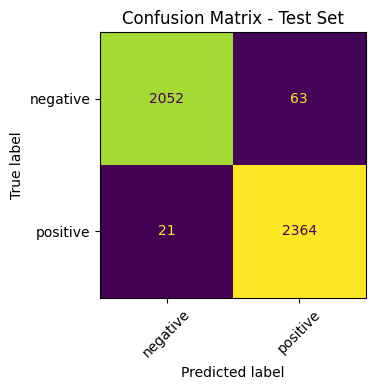

In [14]:
test_pred = best_model.predict(X_test)

print(f'Final Test Macro F1    : {f1_score(y_test, test_pred, average="macro"):.4f}')
print(f'Final Test Weighted F1 : {f1_score(y_test, test_pred, average="weighted"):.4f}')
print(f'Final Test Accuracy    : {accuracy_score(y_test, test_pred):.4f}')
print()
print(classification_report(y_test, test_pred))

cm   = confusion_matrix(y_test, test_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format='d', colorbar=False)
ax.set_title('Confusion Matrix - Test Set')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 13. Error Analysis

Inspecting misclassified examples helps identify patterns in model weaknesses.


In [15]:
err_df = test_df.copy()
err_df['prediction'] = test_pred
err_df['correct']    = err_df['sentiment'] == err_df['prediction']

errors = err_df[~err_df['correct']][['content', 'sentiment', 'prediction']].reset_index(drop=True)
print(f'Total misclassified : {len(errors)} out of {len(test_df)} ({len(errors)/len(test_df):.1%})')
print()
print('Error breakdown by class:')
display(errors.groupby(['sentiment', 'prediction']).size().reset_index(name='count'))
print()
print('Sample misclassified examples (first 20):')
display(errors.head(20))


Total misclassified : 84 out of 4500 (1.9%)

Error breakdown by class:


,sentiment,prediction,count
0,negative,positive,63
1,positive,negative,21



Sample misclassified examples (first 20):


,content,sentiment,prediction
0,"sehabis logout dan masuk lagi, feed makin penuh konten random, ini menghambat kerja harian ini perlu diuji di device mid-range!! #creator versi v32.2.1 Di keranjang, notifikasi koomplain tidak mun...",negative,positive
1,"waktu bikin draft review barang, feed makin penuh konten random, versi lama terasa lebih aman untuk skrg aku kasih rendah! #livestream anjir",negative,positive
2,"sebagai seller aksesoris rumahan, di Balikpapan Selatan, kalau dipakai sambil multitask, tampilan toko enak dilihat, tapi responnya lambat. customer service cuma kirim jawaban umum, ini bikin pros...",negative,positive
3,"di Ciledug, setelah izin aplkiasi diatur ulang, keranjang belanja kembali kosong, masalahnya muncul di waktu yang salah bug ini perlu diprioritaskan. #livestream Di riwayat transaksi, notifikasi k...",negative,positive
4,"barusan aku coba lagi, live shopping lebih stabil, ini bikin aku balik pakai aplikasinya sementara ini aman!! (Poco M4 Pro, Android 14) Device: tablet Android murah, jaringan wifi kos. #orderaman",positive,negative
5,"sebagai mahasiswa rantau, di Condongcatur, buat upload konten kelas, video gagal naik tanpa pesan jelas, kesannya cuma cantik di UI seller kecil bisa rugi kalau begini!! #bugreport. Device: Samsun...",negative,positive
6,"di Pamulang, buat upload konten kelas, inbox suka blank, ini harusnya jadi prioritas bugfix aku berharap ada patch cepat. di Bkasi #supporttemplate",negative,positive
7,"di versi yang baru ini, video gagal naik tanpa pesan jelas, buat user biasa ini membingungkan di perangkatku konsisten gagal. Setelah dicoba 28 order, bikin mikir dua kali buat top up campaiign.",negative,positive
8,"sebagai mahasiswa rantau, setelah izin app diatur ulang, video gagal naik tanpa pesan jelas, versi lama terasa lebih aman lebih baik fix flow utama dulu. Di filter spam, nomor resi tidak bisa disa...",negative,positive
9,"waktu scroll sebelum tidur, invoice terlambat muncul, aku lebih sering nutup app daripada lanjut pakai aku sudah coba reinstall tetap sama? Di profil toko, riwayat pencarian tercampur.",negative,positive


## 14. Top Model Features

Inspecting the highest-weight TF-IDF features per class verifies that the model is learning meaningful sentiment signals rather than noise or template artifacts.


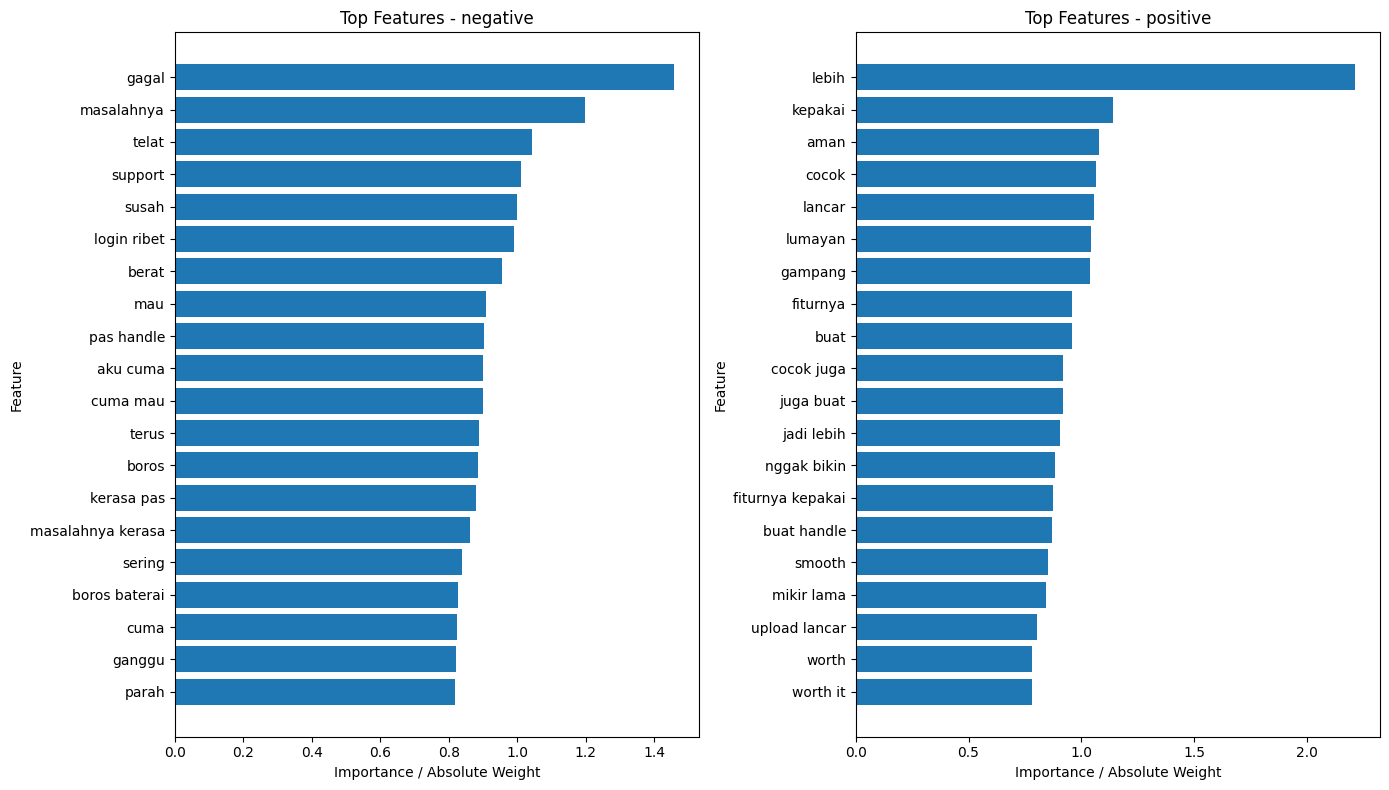

,feature,weight,abs_weight,class
0,gagal,-1.457242,1.457242,negative
1,masalahnya,-1.198675,1.198675,negative
2,telat,-1.042636,1.042636,negative
3,support,-1.010287,1.010287,negative
4,susah,-0.997981,0.997981,negative
5,login ribet,-0.990956,0.990956,negative
6,berat,-0.955798,0.955798,negative
7,mau,-0.909053,0.909053,negative
8,pas handle,-0.903199,0.903199,negative
9,cuma mau,-0.899178,0.899178,negative


In [18]:
from scipy import sparse

def _unwrap_estimator(model):
    """Return the real estimator if the model is wrapped by GridSearchCV."""
    if hasattr(model, 'best_estimator_'):
        return model.best_estimator_
    return model


def _find_vectorizer_and_classifier(model):
    """Find the vectorizer and classifier from a sklearn Pipeline."""
    model = _unwrap_estimator(model)

    if hasattr(model, 'named_steps'):
        steps = model.named_steps

        vectorizer = None
        classifier = None

        for _, step in steps.items():
            if hasattr(step, 'get_feature_names_out'):
                vectorizer = step

            if (
                hasattr(step, 'coef_')
                or hasattr(step, 'feature_log_prob_')
                or hasattr(step, 'feature_importances_')
            ):
                classifier = step

        if vectorizer is None:
            raise ValueError('No vectorizer with get_feature_names_out() was found in the pipeline.')

        if classifier is None:
            raise ValueError('No supported classifier was found in the pipeline.')

        return vectorizer, classifier

    raise ValueError('Expected a sklearn Pipeline or GridSearchCV containing a Pipeline.')


def _to_1d_array(values):
    """Convert sparse, matrix, or 2D values into a clean 1D numpy array."""
    if sparse.issparse(values):
        values = values.toarray()

    values = np.asarray(values)

    if values.ndim > 1:
        values = values.ravel()

    return values.astype(float)


def get_top_features_table(model, class_name=None, top_n=20):
    """
    Return top feature table for linear models, Naive Bayes, or tree-based models.

    For binary linear models with one coefficient row:
    - positive class uses the largest coefficients
    - negative class uses the most negative coefficients
    """
    vectorizer, classifier = _find_vectorizer_and_classifier(model)
    feature_names = np.asarray(vectorizer.get_feature_names_out())

    classes = list(getattr(classifier, 'classes_', []))

    if hasattr(classifier, 'coef_'):
        coef_matrix = classifier.coef_

        if sparse.issparse(coef_matrix):
            coef_matrix = coef_matrix.toarray()

        coef_matrix = np.asarray(coef_matrix)

        # Binary classifiers such as LogisticRegression or LinearSVC often store only one coef row.
        if coef_matrix.shape[0] == 1 and len(classes) == 2:
            coef = _to_1d_array(coef_matrix[0])

            if class_name is None:
                class_name = classes[1]

            if str(class_name).lower() == str(classes[1]).lower():
                indices = np.argsort(coef)[-top_n:][::-1]
                values = coef[indices]
            else:
                indices = np.argsort(coef)[:top_n]
                values = coef[indices]

        else:
            if class_name is None:
                class_name = classes[0]

            class_index = classes.index(class_name)
            coef = _to_1d_array(coef_matrix[class_index])
            indices = np.argsort(coef)[-top_n:][::-1]
            values = coef[indices]

        return pd.DataFrame({
            'feature': feature_names[indices],
            'weight': values,
            'abs_weight': np.abs(values),
            'class': class_name
        })

    if hasattr(classifier, 'feature_log_prob_'):
        # MultinomialNB / ComplementNB
        if class_name is None:
            class_name = classes[0]

        class_index = classes.index(class_name)
        scores = _to_1d_array(classifier.feature_log_prob_[class_index])
        indices = np.argsort(scores)[-top_n:][::-1]

        return pd.DataFrame({
            'feature': feature_names[indices],
            'weight': scores[indices],
            'abs_weight': np.abs(scores[indices]),
            'class': class_name
        })

    if hasattr(classifier, 'feature_importances_'):
        # RandomForest and similar tree-based models do not have class-specific coefficients.
        importances = _to_1d_array(classifier.feature_importances_)
        indices = np.argsort(importances)[-top_n:][::-1]

        return pd.DataFrame({
            'feature': feature_names[indices],
            'weight': importances[indices],
            'abs_weight': importances[indices],
            'class': 'global_importance'
        })

    raise ValueError('This model type is not supported for feature plotting.')


def plot_top_features(model, top_n=20):
    """Plot the most important features for the selected sklearn model."""
    vectorizer, classifier = _find_vectorizer_and_classifier(model)
    classes = list(getattr(classifier, 'classes_', []))

    if hasattr(classifier, 'feature_importances_'):
        tables = [get_top_features_table(model, top_n=top_n)]
    else:
        tables = [
            get_top_features_table(model, class_name=label, top_n=top_n)
            for label in classes
        ]

    n_plots = len(tables)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 8))

    if n_plots == 1:
        axes = [axes]

    for ax, table in zip(axes, tables):
        plot_table = table.sort_values('abs_weight', ascending=True)

        ax.barh(
            plot_table['feature'].astype(str),
            plot_table['abs_weight'].astype(float)
        )

        class_label = str(table['class'].iloc[0])
        ax.set_title(f'Top Features - {class_label}')
        ax.set_xlabel('Importance / Absolute Weight')
        ax.set_ylabel('Feature')

    plt.tight_layout()
    plt.show()

    return pd.concat(tables, ignore_index=True)


top_features_df = plot_top_features(best_model, top_n=20)
display(top_features_df)

## 15. Model Comparison: Logistic Regression

Logistic Regression provides calibrated probability scores, which is useful when the application needs confidence estimates rather than hard labels.


In [19]:
#  Full model comparison (all 4 ML models vs each other) 
comparison_rows = []

for name, pipe in trained_models.items():
    # Use tuned version for the best model
    model_to_eval = best_model if name == baseline_df.iloc[0]['Model'] else pipe
    val_p  = model_to_eval.predict(X_val)
    test_p = model_to_eval.predict(X_test)
    label  = name + (' (tuned)' if name == baseline_df.iloc[0]['Model'] else '')
    comparison_rows.append({
        'Model'           : label,
        'Val Macro F1'    : round(f1_score(y_val,  val_p,  average='macro'), 4),
        'Test Macro F1'   : round(f1_score(y_test, test_p, average='macro'), 4),
        'Test Weighted F1': round(f1_score(y_test, test_p, average='weighted'), 4),
        'Test Accuracy'   : round(accuracy_score(y_test, test_p), 4),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('Test Macro F1', ascending=False).reset_index(drop=True)
print('=== ML Model Comparison (Test Set) ===')
display(comparison_df)

# Persist test predictions for the best (tuned) model
test_pred = best_model.predict(X_test)

# Also save all models
for name, pipe in trained_models.items():
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '_model.joblib'
    joblib.dump(pipe, fname)
    print(f'Saved: {fname}')
joblib.dump(best_model, 'best_model_tuned.joblib')
print('Saved: best_model_tuned.joblib')


=== ML Model Comparison (Test Set) ===


,Model,Val Macro F1,Test Macro F1,Test Weighted F1,Test Accuracy
0,Logistic Regression,0.9995,0.9819,0.9820,0.9820
1,SVM (Linear Kernel) (tuned),1.0000,0.9812,0.9813,0.9813
2,Random Forest,0.9995,0.9712,0.9713,0.9713
3,Naive Bayes,1.0000,0.9701,0.9702,0.9702


Saved: logistic_regression_model.joblib
Saved: svm_linear_kernel_model.joblib
Saved: naive_bayes_model.joblib
Saved: random_forest_model.joblib
Saved: best_model_tuned.joblib


## 16. Save Model

The complete pipeline (TextCleaner + TF-IDF + classifier) is saved to a `.joblib` file.


In [20]:
MODEL_PATH = 'tiktok_sentiment_model.joblib'
joblib.dump(best_model, MODEL_PATH)
print(f'Model saved to: {MODEL_PATH}')


Model saved to: tiktok_sentiment_model.joblib


## 17. Inference on New Text

Use the function below to predict sentiment for new TikTok review text.


In [21]:
def _get_model_classes(model):
    """Return class names from a sklearn Pipeline or estimator when available."""
    if hasattr(model, 'classes_'):
        return list(model.classes_)
    if hasattr(model, 'named_steps') and 'clf' in model.named_steps:
        clf = model.named_steps['clf']
        if hasattr(clf, 'classes_'):
            return list(clf.classes_)
    return None


def predict_sentiment(texts, model=best_model):
    """Predict sentiment for a single string or a list of Indonesian review strings."""
    if isinstance(texts, str):
        texts = [texts]

    texts = [str(text) for text in texts]
    preds = model.predict(texts)

    result = pd.DataFrame({
        'content': texts,
        'predicted_sentiment': preds,
    })

    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(texts)
        result['confidence'] = probs.max(axis=1).round(4)

    return result


model_classes = _get_model_classes(best_model)
print('Model classes:', model_classes)

# Use Indonesian samples because the TF-IDF model was trained on Indonesian TikTok review text.
sample_texts = [
    'aplikasinya sering crash dan bikin baterai cepat habis',
    'fitur duetnya keren banget dan mudah dipakai',
    'notifikasi tidak muncul sama sekali, bikin frustrasi',
    'pengalaman pakainya lancar dan tampilannya nyaman',
]

display(predict_sentiment(sample_texts))


Model classes: ['negative', 'positive']


,content,predicted_sentiment,confidence
0,aplikasinya sering crash dan bikin baterai cepat habis,negative,0.9749
1,fitur duetnya keren banget dan mudah dipakai,positive,0.9303
2,"notifikasi tidak muncul sama sekali, bikin frustrasi",positive,0.8457
3,pengalaman pakainya lancar dan tampilannya nyaman,positive,1.0000


## 17.1 Hate Speech Ensemble Override

This section keeps the original sentiment model unchanged. It adds a second classifier that can override the sentiment output when hate speech is detected with high confidence.

The goal is to prevent toxic or hateful input from being classified as positive only because the main sentiment model was trained on product-review sentiment patterns.


In [22]:
# Hate speech ensemble override for inference.
# This keeps the existing sentiment pipeline unchanged.
# The hate speech model acts only as a high-confidence safety override.
# The auxiliary hate model is forced to CPU so the T4 GPU stays reserved for IndoBERT.

import gc
import torch
from transformers import AutoConfig, pipeline

HATE_MODEL_NAME = "Hate-speech-CNERG/dehatebert-mono-english"
HATE_THRESHOLD = 0.92

# Delete any stale pipeline object from previous runs.
# This prevents an old CUDA-based hate_pipe from staying in memory after rerunning the cell.
if 'hate_pipe' in globals():
    del hate_pipe
gc.collect()

hate_config = AutoConfig.from_pretrained(HATE_MODEL_NAME)
print("Hate model labels:", hate_config.id2label)


# Force CPU for the auxiliary hate model.
# Do not set CUDA_VISIBLE_DEVICES here because IndoBERT should still use the T4 GPU later.
HATE_DEVICE = -1

hate_pipe = pipeline(
    "text-classification",
    model=HATE_MODEL_NAME,
    device=HATE_DEVICE,
)

# Make the device placement explicit even if the pipeline was previously created on CUDA.
hate_pipe.model.to("cpu")
print("Hate pipeline device:", hate_pipe.device)


def _normalize_hate_label(label):
    """Normalize the hate classifier label for safer comparisons."""
    return str(label).strip().upper().replace("-", "_").replace(" ", "_")


def _is_actual_hate_label(label):
    """
    Return True only for real hate labels.

    Important:
    NON_HATE and NOT_HATE contain the word HATE, so substring checks are unsafe.
    """
    normalized = _normalize_hate_label(label)

    non_hate_labels = {
        "NON_HATE",
        "NONHATE",
        "NOT_HATE",
        "NOTHATE",
        "NO_HATE",
        "NOHATE",
        "NON_HATEFUL",
        "NONHATEFUL",
        "NOT_HATEFUL",
        "NOTHATEFUL",
        "NORMAL",
        "NEUTRAL",
        "CLEAN",
    }
    if normalized in non_hate_labels:
        return False

    exact_hate_labels = {
        "HATE",
        "HATEFUL",
        "HATE_SPEECH",
        "OFFENSIVE",
        "ABUSIVE",
        "TOXIC",
    }
    return normalized in exact_hate_labels


def _get_hate_labels_from_config(config):
    """Get only true hate-class labels from the model config."""
    hate_labels = set()

    for _, label in config.id2label.items():
        normalized = _normalize_hate_label(label)
        if _is_actual_hate_label(normalized):
            hate_labels.add(normalized)

    if not hate_labels:
        # If the model exposes generic labels such as LABEL_0 or LABEL_1,
        # do not guess the mapping. A wrong override is worse than no override.
        print("Warning: no explicit hate label found in model config. Override will be conservative.")

    return hate_labels


HATE_LABELS = _get_hate_labels_from_config(hate_config)
print("Labels treated as hate:", HATE_LABELS)


def _get_hate_result(text):
    """
    Return the hate classifier's top prediction for one text.
    Per-text inference avoids the stale CUDA batch path seen in the earlier error.
    """
    out = hate_pipe(
        str(text),
        truncation=True,
        max_length=128,
    )

    if isinstance(out, list) and len(out) > 0:
        if isinstance(out[0], list) and len(out[0]) > 0:
            return out[0][0]
        return out[0]

    raise ValueError(f"Unexpected hate model output: {out}")


def predict_sentiment_ensemble(texts, ml_model=best_model, threshold=HATE_THRESHOLD):
    """
    Ensemble rule:
    - If the hate speech model predicts an actual hate label with high confidence,
      override the output to negative.
    - Otherwise, trust the original Indonesian sentiment model.

    The default threshold is intentionally high because the hate model is English-only.
    """
    if isinstance(texts, str):
        texts = [texts]

    texts = [str(text) for text in texts]
    results = []

    for text in texts:
        hate_out = _get_hate_result(text)
        hate_label = _normalize_hate_label(hate_out["label"])
        hate_conf = float(hate_out["score"])

        is_hate = hate_label in HATE_LABELS

        if is_hate and hate_conf >= threshold:
            results.append({
                "content": text,
                "predicted_sentiment": "negative",
                "hate_label": hate_out["label"],
                "hate_confidence": round(hate_conf, 4),
                "source": "hate_model_override",
            })
        else:
            pred = ml_model.predict([text])[0]
            results.append({
                "content": text,
                "predicted_sentiment": pred,
                "hate_label": hate_out["label"],
                "hate_confidence": round(hate_conf, 4),
                "source": "sentiment_model",
            })

    return pd.DataFrame(results)


ensemble_sample_texts = [
    'aplikasinya sering crash dan bikin kesel',
    'bagus banget, fiturnya lancar dan nyaman dipakai',
    'you are worthless and stupid',
    'fitur duetnya keren, sering aku pakai',
]

display(predict_sentiment_ensemble(ensemble_sample_texts, threshold=HATE_THRESHOLD))


Hate model labels: {0: 'NON_HATE', 1: 'HATE'}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Hate pipeline device: cpu
Labels treated as hate: {'HATE'}


,content,predicted_sentiment,hate_label,hate_confidence,source
0,aplikasinya sering crash dan bikin kesel,negative,NON_HATE,0.9473,sentiment_model
1,"bagus banget, fiturnya lancar dan nyaman dipakai",positive,NON_HATE,0.9539,sentiment_model
2,you are worthless and stupid,negative,NON_HATE,0.5291,sentiment_model
3,"fitur duetnya keren, sering aku pakai",negative,NON_HATE,0.9740,sentiment_model


## 18. Data Leakage Audit

This section explicitly checks target leakage risks before adding IndoBERT.

Key rule: the models may use **only `content` as input**. The `score` column is retained only for EDA because it maps directly to `sentiment`.


In [23]:
def leakage_audit(train_df, test_df):
    print('=== Schema ===')
    print('Train columns:', train_df.columns.tolist())
    print('Test columns :', test_df.columns.tolist())

    print('\n=== Target-like columns check ===')
    forbidden_features = {'sentiment', 'score', '_is_augmented', 'label', 'target'}
    used_feature_columns = {'content'}
    accidental = used_feature_columns & forbidden_features
    if accidental:
        raise ValueError(f'Leakage risk: forbidden feature(s) used: {accidental}')
    print('OK: model input uses content only.')

    print('\n=== score -> sentiment relationship ===')
    if 'score' in train_df.columns:
        score_map = pd.crosstab(train_df['score'], train_df['sentiment'], normalize='index')
        display(score_map.round(3))
        print('Interpretation: if each score value maps to only one sentiment, score is target leakage and must not be used for training.')
    else:
        print('No score column found.')

    print('\n=== Exact duplicate / overlap check ===')
    train_dup = train_df.duplicated(subset='content').sum()
    test_dup  = test_df.duplicated(subset='content').sum()
    overlap   = len(set(train_df['content'].astype(str)) & set(test_df['content'].astype(str)))
    print(f'Train duplicate content: {train_dup}')
    print(f'Test duplicate content : {test_dup}')
    print(f'Exact train-test content overlap: {overlap}')

    print('\n=== N-gram overlap check ===')
    def _norm(text):
        text = str(text).lower()
        text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
        return re.sub(r'\s+', ' ', text).strip()

    def _ngrams(series, n):
        grams = set()
        for text in series.astype(str):
            tokens = _norm(text).split()
            grams.update(tuple(tokens[i:i+n]) for i in range(max(0, len(tokens) - n + 1)))
        return grams

    rows = []
    for n in [2, 3, 4, 5]:
        train_grams = _ngrams(train_df['content'], n)
        test_grams  = _ngrams(test_df['content'], n)
        shared = len(train_grams & test_grams)
        total_test = max(1, len(test_grams))
        rows.append({
            'n': n,
            'shared_ngrams': shared,
            'test_ngrams': len(test_grams),
            'overlap_rate': shared / total_test,
        })
    display(pd.DataFrame(rows).assign(overlap_rate=lambda d: (d['overlap_rate'] * 100).round(2)))

leakage_audit(train_df, test_df)


=== Schema ===
Train columns: ['content', 'score', 'sentiment', 'word_count']
Test columns : ['content', 'score', 'sentiment', 'word_count']

=== Target-like columns check ===
OK: model input uses content only.

=== score -> sentiment relationship ===


sentiment,negative,positive
score,,
1,1.000,0.000
2,1.000,0.000
3,0.638,0.362
4,0.069,0.931
5,0.000,1.000


Interpretation: if each score value maps to only one sentiment, score is target leakage and must not be used for training.

=== Exact duplicate / overlap check ===
Train duplicate content: 0
Test duplicate content : 0
Exact train-test content overlap: 0

=== N-gram overlap check ===


,n,shared_ngrams,test_ngrams,overlap_rate
0,2,6932,15826,43.80
1,3,11137,34537,32.25
2,4,12587,53288,23.62
3,5,11862,70454,16.84


## 19. IndoBERT Fine-Tuning

This adds an IndoBERT baseline using `indobenchmark/indobert-base-p1`.

Notes:
- Use a **GPU T4 runtime** for this section.
- The notebook installs PyTorch at the top of the notebook, not in the middle of the run.
- Do not run this section on P100 with the cu124 PyTorch wheel.
- `score` is not used as an input feature, so it does not create target leakage.


In [24]:
# Runtime check for the T4 GPU setup.
# PyTorch is installed in the first cell. Do not reinstall it here because torch was already imported earlier.

import subprocess
import torch

REQUIRE_T4_GPU = True

print(f"Torch version : {torch.__version__}")
print(f"Torch CUDA    : {torch.version.cuda}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA GPU was detected. Switch the notebook accelerator to GPU T4, then Restart & Run All."
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)
print(f"GPU detected  : {gpu_name}")
print(f"Capability    : sm_{gpu_capability[0]}{gpu_capability[1]}")

if REQUIRE_T4_GPU and "T4" not in gpu_name.upper():
    raise RuntimeError(
        f"This notebook is configured for GPU T4 only. Detected: {gpu_name}. "
        "Switch the accelerator to T4, then Restart & Run All."
    )

# Run a small CUDA operation only after confirming that the detected GPU is T4.
_test_tensor = torch.tensor([1.0], device="cuda") * 2
torch.cuda.synchronize()
print("CUDA test     : passed")


Torch version : 2.6.0+cu124
Torch CUDA    : 12.4
GPU detected  : Tesla T4
Capability    : sm_75
CUDA test     : passed


In [25]:
import os
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

set_seed(42)

# Device setup with explicit T4 validation.
def get_device(require_t4=True):
    """Return the CUDA device only when the runtime is the requested T4 GPU."""
    if not torch.cuda.is_available():
        raise RuntimeError(
            "No GPU found. Switch the notebook accelerator to GPU T4, then Restart & Run All."
        )

    name = torch.cuda.get_device_name(0)
    cap = torch.cuda.get_device_capability(0)
    print(f"GPU  : {name}")
    print(f"Cap  : sm_{cap[0]}{cap[1]}")
    print(f"CUDA : {torch.version.cuda}")

    if require_t4 and "T4" not in name.upper():
        raise RuntimeError(
            f"This run detected {name}, not T4. "
            "Switch the runtime accelerator to GPU T4 and restart the notebook."
        )

    try:
        torch.tensor([1.0], device="cuda") * 2
        torch.cuda.synchronize()
    except Exception as e:
        raise RuntimeError(
            "CUDA is visible but cannot run kernels. "
            "Restart the runtime and make sure the accelerator is GPU T4."
        ) from e

    return torch.device('cuda'), True


DEVICE, USE_GPU = get_device(require_t4=True)

# IndoBERT settings.
MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LENGTH = 96
INDOBERT_FAST_MODE = True
INDOBERT_MAX_TRAIN_SAMPLES = 3000
INDOBERT_MAX_VAL_SAMPLES = 800
INDOBERT_MAX_TEST_SAMPLES = None

# Build label2id dynamically from actual data labels.
# This keeps the notebook safe if the dataset labels change later.
all_labels = sorted(set(y_train.astype(str).str.lower()) | set(y_val.astype(str).str.lower()))
label2id = {lbl: idx for idx, lbl in enumerate(all_labels)}
id2label = {v: k for k, v in label2id.items()}
print(f"Labels detected: {label2id}")

def bert_text_normalize(text):
    """
    Apply minimal cleaning for IndoBERT.
    Slang, typos, and word order are preserved because BERT uses context.
    """
    text = html.unescape(str(text))
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def encode_labels(labels):
    """Encode string labels using the label2id mapping built from the training data."""
    series = pd.Series(labels).astype(str).str.lower()
    unknown = set(series) - set(label2id)
    if unknown:
        raise ValueError(f'Unknown labels found: {unknown}')
    return series.map(label2id).astype(int).tolist()

def limit_bert_samples(texts, labels, max_samples=None, random_state=42):
    """
    Use a stratified subset for faster IndoBERT fine-tuning.
    This prevents long Kaggle/Colab runs while preserving label balance.
    """
    texts = pd.Series(texts).reset_index(drop=True)
    labels = pd.Series(labels).reset_index(drop=True).astype(str).str.lower()

    if max_samples is None or len(texts) <= max_samples:
        return texts, labels

    tmp = pd.DataFrame({'content': texts, 'sentiment': labels})
    sampled_parts = []

    for label, group in tmp.groupby('sentiment'):
        label_ratio = len(group) / len(tmp)
        label_n = max(1, int(round(max_samples * label_ratio)))
        label_n = min(label_n, len(group))
        sampled_parts.append(group.sample(n=label_n, random_state=random_state))

    sampled = pd.concat(sampled_parts, axis=0)

    if len(sampled) > max_samples:
        sampled = sampled.sample(n=max_samples, random_state=random_state)

    sampled = sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return sampled['content'], sampled['sentiment']

# Use smaller IndoBERT subsets by default to avoid KeyboardInterrupt from long training.
# Set INDOBERT_FAST_MODE = False if you want full fine-tuning later.
if INDOBERT_FAST_MODE:
    X_train_bert_src, y_train_bert_src = limit_bert_samples(X_train, y_train, INDOBERT_MAX_TRAIN_SAMPLES)
    X_val_bert_src, y_val_bert_src = limit_bert_samples(X_val, y_val, INDOBERT_MAX_VAL_SAMPLES)
    X_test_bert_src, y_test_bert_src = limit_bert_samples(X_test, y_test, INDOBERT_MAX_TEST_SAMPLES)
else:
    X_train_bert_src, y_train_bert_src = X_train, y_train
    X_val_bert_src, y_val_bert_src = X_val, y_val
    X_test_bert_src, y_test_bert_src = X_test, y_test

# Tokenize texts.
train_texts_bert = pd.Series(X_train_bert_src).map(bert_text_normalize).tolist()
val_texts_bert = pd.Series(X_val_bert_src).map(bert_text_normalize).tolist()
test_texts_bert = pd.Series(X_test_bert_src).map(bert_text_normalize).tolist()

y_train_bert = encode_labels(y_train_bert_src)
y_val_bert = encode_labels(y_val_bert_src)
y_test_bert = encode_labels(y_test_bert_src)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TikTokSentimentDataset(Dataset):
    """Torch Dataset wrapper for tokenized TikTok review text."""

    def __init__(self, texts, labels=None):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=MAX_LENGTH,
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = TikTokSentimentDataset(train_texts_bert, y_train_bert)
val_dataset = TikTokSentimentDataset(val_texts_bert, y_val_bert)
test_dataset = TikTokSentimentDataset(test_texts_bert, y_test_bert)

# Load the IndoBERT classification model.
# Do not force safetensors because some IndoBERT checkpoints are published as pytorch_model.bin.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
).to(DEVICE)

print(f"\nModel loaded on : {DEVICE}")
print(f"Fast mode       : {INDOBERT_FAST_MODE}")
print(f"Max length      : {MAX_LENGTH}")
print(f"Train samples   : {len(train_dataset):,}")
print(f"Val samples     : {len(val_dataset):,}")
print(f"Test samples    : {len(test_dataset):,}")
print(f"Torch version   : {torch.__version__}")


GPU  : Tesla T4
Cap  : sm_75
CUDA : 12.4
Labels detected: {'negative': 0, 'positive': 1}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded on : cuda
Fast mode       : True
Max length      : 96
Train samples   : 3,000
Val samples     : 800
Test samples    : 4,500
Torch version   : 2.6.0+cu124


In [26]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
    }

# These settings make IndoBERT practical on Kaggle/Colab.
# Increase max_steps or disable fast mode only after the full notebook runs successfully.
MAX_TRAINING_STEPS = 250 if INDOBERT_FAST_MODE else -1
EVAL_STEPS = 50 if INDOBERT_FAST_MODE else 200
SAVE_STEPS = EVAL_STEPS

training_args = TrainingArguments(
    output_dir='indobert_tiktok_checkpoints',
    eval_strategy='steps',
    save_strategy='steps',
    eval_steps=EVAL_STEPS,
    save_steps=SAVE_STEPS,
    learning_rate=2e-5,
    per_device_train_batch_size=16 if USE_GPU else 4,
    per_device_eval_batch_size=32 if USE_GPU else 8,
    num_train_epochs=1 if INDOBERT_FAST_MODE else 3,
    max_steps=MAX_TRAINING_STEPS,
    weight_decay=0.01,
    warmup_ratio=0.06,
    fp16=USE_GPU,
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model='eval_macro_f1',
    greater_is_better=True,
    save_total_limit=1,
    report_to='none',
    seed=42,
)

# processing_class is used in newer transformers versions.
# tokenizer is used as a fallback for older versions.
import transformers
_hf_version = tuple(int(x) for x in transformers.__version__.split(".")[:2])
_trainer_tokenizer_kwarg = (
    {"processing_class": tokenizer} if _hf_version >= (4, 46)
    else {"tokenizer": tokenizer}
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    **_trainer_tokenizer_kwarg,
)

# KeyboardInterrupt means the run was stopped manually, not that the model code is broken.
# If it happens again, the notebook will still evaluate the current model state instead of crashing.
try:
    train_result = trainer.train()
    print('Training finished successfully.')
except KeyboardInterrupt:
    train_result = None
    print('Training was interrupted manually. Continuing with the current model state.')

val_metrics = trainer.evaluate(val_dataset)
print('Validation metrics:')
print(val_metrics)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
50,0.039090,0.028256,0.996250,0.996211,0.996250
100,0.000525,0.026792,0.997500,0.997475,0.997500
150,0.000454,0.016027,0.998750,0.998738,0.998750
200,0.000262,0.005832,0.998750,0.998738,0.998750
250,0.000254,0.005058,0.998750,0.998738,0.998750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training finished successfully.


Validation metrics:
{'eval_loss': 0.0159973856061697, 'eval_accuracy': 0.99875, 'eval_macro_f1': 0.9987376905101151, 'eval_weighted_f1': 0.9987501558163276, 'eval_runtime': 2.9562, 'eval_samples_per_second': 270.62, 'eval_steps_per_second': 4.398, 'epoch': 2.6595744680851063}


IndoBERT Test Macro F1    : 0.9973
IndoBERT Test Weighted F1 : 0.9973
IndoBERT Test Accuracy    : 0.9973

              precision    recall  f1-score   support

    negative       1.00      0.99      1.00      2115
    positive       1.00      1.00      1.00      2385

    accuracy                           1.00      4500
   macro avg       1.00      1.00      1.00      4500
weighted avg       1.00      1.00      1.00      4500



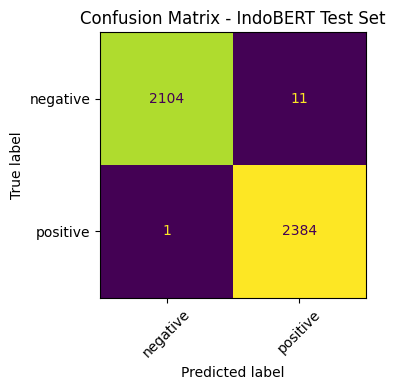

In [27]:
# Final IndoBERT test evaluation.
indobert_test_output = trainer.predict(test_dataset)
indobert_test_logits = indobert_test_output.predictions
indobert_test_pred_ids = np.argmax(indobert_test_logits, axis=-1)
indobert_test_pred = [id2label[int(i)] for i in indobert_test_pred_ids]
y_test_bert_labels = pd.Series(y_test_bert_src).astype(str).str.lower().tolist()

print(f'IndoBERT Test Macro F1    : {f1_score(y_test_bert_labels, indobert_test_pred, average="macro"):.4f}')
print(f'IndoBERT Test Weighted F1 : {f1_score(y_test_bert_labels, indobert_test_pred, average="weighted"):.4f}')
print(f'IndoBERT Test Accuracy    : {accuracy_score(y_test_bert_labels, indobert_test_pred):.4f}')
print()
print(classification_report(y_test_bert_labels, indobert_test_pred))

cm_labels = sorted(label2id.keys())
cm = confusion_matrix(y_test_bert_labels, indobert_test_pred, labels=cm_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cm_labels)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format='d', colorbar=False)
ax.set_title('Confusion Matrix - IndoBERT Test Set')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Final comparison: all ML models + IndoBERT.
final_rows = []

for name, pipe in trained_models.items():
    model_to_eval = best_model if name == baseline_df.iloc[0]['Model'] else pipe
    test_p = model_to_eval.predict(X_test)
    label = name + (' (tuned)' if name == baseline_df.iloc[0]['Model'] else '')
    final_rows.append({
        'Model': label,
        'Test Macro F1': round(f1_score(y_test, test_p, average='macro'), 4),
        'Test Weighted F1': round(f1_score(y_test, test_p, average='weighted'), 4),
        'Test Accuracy': round(accuracy_score(y_test, test_p), 4),
    })

if 'indobert_test_pred' in globals():
    # IndoBERT may use a smaller test subset in fast mode, so it is evaluated on y_test_bert_labels.
    final_rows.append({
        'Model': 'IndoBERT (fine-tuned, fast mode)' if INDOBERT_FAST_MODE else 'IndoBERT (fine-tuned)',
        'Test Macro F1': round(f1_score(y_test_bert_labels, indobert_test_pred, average='macro'), 4),
        'Test Weighted F1': round(f1_score(y_test_bert_labels, indobert_test_pred, average='weighted'), 4),
        'Test Accuracy': round(accuracy_score(y_test_bert_labels, indobert_test_pred), 4),
    })

final_df = pd.DataFrame(final_rows).sort_values('Test Macro F1', ascending=False).reset_index(drop=True)
print('=== Final Model Comparison (All Models) ===')
display(final_df)

=== Final Model Comparison (All Models) ===


,Model,Test Macro F1,Test Weighted F1,Test Accuracy
0,"IndoBERT (fine-tuned, fast mode)",0.9973,0.9973,0.9973
1,Logistic Regression,0.9819,0.9820,0.9820
2,SVM (Linear Kernel) (tuned),0.9812,0.9813,0.9813
3,Random Forest,0.9712,0.9713,0.9713
4,Naive Bayes,0.9701,0.9702,0.9702


In [30]:
# Save IndoBERT model and tokenizer.
INDOBERT_SAVE_DIR = 'indobert_tiktok_sentiment'
trainer.save_model(INDOBERT_SAVE_DIR)
tokenizer.save_pretrained(INDOBERT_SAVE_DIR)
print(f'IndoBERT model saved to: {INDOBERT_SAVE_DIR}')

def predict_sentiment_indobert(texts):
    """Predict sentiment for a single string or a list of strings using the fine-tuned IndoBERT model."""
    if isinstance(texts, str):
        texts = [texts]

    clean_texts = [bert_text_normalize(t) for t in texts]
    device = torch.device('cuda' if globals().get('USE_GPU', False) else 'cpu')
    model.to(device)
    model.eval()

    inputs = tokenizer(
        clean_texts,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        pred_ids = probs.argmax(axis=-1)

    return pd.DataFrame({
        'content': texts,
        'predicted_sentiment': [id2label[int(i)] for i in pred_ids],
        'confidence': probs.max(axis=-1).round(4),
    })

sample_texts_bert = [
    'kamu keren banget bro',
    'aplikasinya sering crash dan bikin kesel',
    'bagus banget, pengiriman cepat dan packaging aman',
]
display(predict_sentiment_indobert(sample_texts_bert))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

IndoBERT model saved to: indobert_tiktok_sentiment


,content,predicted_sentiment,confidence
0,kamu keren banget bro,positive,0.9888
1,aplikasinya sering crash dan bikin kesel,negative,0.9998
2,"bagus banget, pengiriman cepat dan packaging aman",positive,0.9999


## Methodology Notes

1. The `score` column is excluded from training due to perfect correlation with `sentiment` (data leakage).
2. The test set is evaluated only once, after model selection is finalized.
3. Hyperparameter tuning uses cross-validation on the training split only.
4. Regularization is controlled via the `C` parameter in LinearSVC.
5. Emojis are converted to sentiment tokens rather than discarded, preserving their signal.
6. This dataset is fully synthetic; model performance may differ on real TikTok reviews.
7. Macro F1 is the primary evaluation metric as it treats each class equally regardless of size.
8. IndoBERT is fine-tuned using the same train/validation/test separation and uses `content` only as input.
